###  TypeError: Cannot interpret '<attribute 'dtype' of 'numpy.generic' objects>' as a data type 
#### 가 발생하는 경우가 있습니다. 이것은 pandas 버전과 numpy의 버전이 맞지않은 경우에 발생합니다.
#### 위의 에러가 발생하는 경우에는, 
#### (1) pip 버전 업그레이드 : (anaconda prompt "관리자권한 실행" 후) python.exe -m pip install --upgrade pip
#### (2) pandas 버전 업그레이드 : (Jupyter Notebook "관리자권한 실행" 후) !pip install pandas --upgrade
#### (3) numpy 버전 업그레이드 :  (Jupyter Notebook "관리자권한 실행" 후) !pip install numpy --upgrade
#### 를 하시기 바랍니다.

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

# 7장. 통계분석

# [1] 와인 품질 등급 예측하기

#### p.201
## 4. 데이터준비
### 4.1 다운로드한 CSV 파일 정리하기

In [2]:
import pandas as pd

In [7]:
red_df = pd.read_csv('./7장_data/winequality-red.csv', sep = ';', header = 0, engine = 'python')

In [8]:
red_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [9]:
white_df = pd.read_csv('./7장_data/winequality-white.csv', sep = ';', header = 0, engine= 'python')

In [10]:
white_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [11]:
red_df.to_csv('./7장_data/winequality-red2.csv',index = False)

In [12]:
red_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [13]:
white_df.to_csv('./7장_data/winequality-white2.csv', index = False)

In [14]:
white_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


### 4.2 데이터 병합하기

In [15]:
red_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
red_df.insert(0, column = 'type', value = 'red')

In [17]:
red_df.head()  #작업 확인용 출력

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
red_df.shape

(1599, 13)

In [19]:
white_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [21]:
white_df.insert(0, column = 'type', value = 'white')

In [22]:
white_df.head()    #작업 확인용 출력

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [23]:
white_df.shape

(4898, 13)

In [24]:
wine = pd.concat([red_df, white_df])

In [25]:
wine.shape

(6497, 13)

In [28]:
wine.to_csv('./7장_data/wine.csv', index = False)

## 5. 데이터 탐색

In [29]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 710.6+ KB


#### 컬럼이름의 띄어쓰기를 밑줄로 바꾸기

In [30]:
wine.columns = wine.columns.str.replace(' ', '_')

- 머신러닝은 공백을 싫어함: 언더바(스네이크식) 혹은 카멜식 표기법으로 변경해 출력할 것을 권장

In [31]:
wine.head()  #작업 확인용 출력

,type,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [35]:
wine.describe
#describe()와 달리 데이터 표기만 해주는 이유는 bound method NDFrame.describe of 때문

<bound method NDFrame.describe of        type  fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
0       red            7.4              0.70         0.00             1.9   
1       red            7.8              0.88         0.00             2.6   
2       red            7.8              0.76         0.04             2.3   
3       red           11.2              0.28         0.56             1.9   
4       red            7.4              0.70         0.00             1.9   
...     ...            ...               ...          ...             ...   
4893  white            6.2              0.21         0.29             1.6   
4894  white            6.6              0.32         0.36             8.0   
4895  white            6.5              0.24         0.19             1.2   
4896  white            5.5              0.29         0.30             1.1   
4897  white            6.0              0.21         0.38             0.8   

      chlorides  free_sulfur_dioxide  tot

In [33]:
wine.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [36]:
sorted(wine.quality.unique())

[np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)]

In [44]:
l = sorted(wine.quality.unique())
l2 = list(map(int, l))
l2

[3, 4, 5, 6, 7, 8, 9]

In [45]:
wine.quality.value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

## 6. 데이터 모델링

### 6.1 describe( ) 함수로 그룹 비교하기

In [46]:
wine.groupby('type')['quality'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
red,1599.0,5.636023,0.807569,3.0,5.0,6.0,6.0,8.0
white,4898.0,5.877909,0.885639,3.0,5.0,6.0,6.0,9.0


In [47]:
wine.groupby('type')['quality'].mean()

type
red      5.636023
white    5.877909
Name: quality, dtype: float64

In [48]:
wine.groupby('type')['quality'].std()

type
red      0.807569
white    0.885639
Name: quality, dtype: float64

In [49]:
wine.groupby('type')['quality'].agg(['mean', 'std'])

,mean,std
type,,
red,5.636023,0.807569
white,5.877909,0.885639


In [50]:
wine.groupby('type')['quality'].agg(['mean', 'std', lambda x: x.quantile(0.25)])

,mean,std,<lambda_0>
type,,,
red,5.636023,0.807569,5.0
white,5.877909,0.885639,5.0


In [52]:
wine.groupby('type')['quality'].describe()[['mean', 'std', '25%']]

,mean,std,25%
type,,,
red,5.636023,0.807569,5.0
white,5.877909,0.885639,5.0


### 6.2 t-검정과 회귀 분석으로 그룹 비교하기

In [ ]:
# 통계 라이브러리 설치 : 한번만 실행
! pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
from scipy import stats #t-검정

In [85]:
from statsmodels.formula.api import ols, glm #회귀분석/ ols: 선형회귀분석 모델, glm: 로지스틱 회귀, 이분형 데이터 등 여러 분야

In [86]:
red_wine_quality = wine.loc[wine['type'] == 'red', 'quality']

In [87]:
red_wine_quality

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64

In [88]:
white_wine_quality = wine.loc[wine['type'] == 'white', 'quality']

In [89]:
white_wine_quality

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

In [ ]:
stats.ttest_ind(red_wine_quality, white_wine_quality, equal_var = False)
#equal_var: 등분산성
#statistic: 절댓값이 클수록 값간 차이가 있겠다
#pvalue: 작을수록(0에 가까울수록) 차이가 유의미하다! "0.05"를 기준으로 차이가 유의미한지 여부를 알 수 있음.
#df: 자유도. 표본 수치에 따라가는 편.

TtestResult(statistic=np.float64(-10.149363059143164), pvalue=np.float64(8.168348870049682e-24), df=np.float64(2950.750452166697))

In [96]:
wine.groupby('type')['alcohol'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
red,1599.0,10.422983,1.065668,8.4,9.5,10.2,11.1,14.9
white,4898.0,10.514267,1.230621,8.0,9.5,10.4,11.4,14.2


In [98]:
white_wine_alcohol = wine.loc[wine['type'] == 'white', 'alcohol']
red_wine_alcohol = wine.loc[wine['type'] == 'red', 'alcohol']

stats.ttest_ind(red_wine_alcohol, white_wine_alcohol, equal_var = False)

TtestResult(statistic=np.float64(-2.8590287839639132), pvalue=np.float64(0.004277779864993421), df=np.float64(3100.474621253641))

------------------------

In [99]:
Rformula = 'quality ~ fixed_acidity + volatile_acidity + citric_acid + \
            residual_sugar + chlorides + free_sulfur_dioxide + \
            total_sulfur_dioxide + density + pH + sulphates + alcohol'

In [ ]:
regression_result = ols(Rformula, data = wine).fit() #.fit(): '(앞의 내용)에 맞게 모델 돌려라'라는 의미

In [ ]:
regression_result.summary()
#coef: 절댓값이 커질수록 기준(quality로 정한 것, Rformula)의 값이 커지는 것
#R-squared: (변수*coef)의 합의 평균(%)
#Adj. R-squared: 변수가 많을 때 R-squared를 계산하는 방법
#Prob (F-statistic): t검정의 statistic, 0.05보다 작으면 유의미한 값 차이 존재함을 의미
#P>|t|: 0.05보다 작으면 통계적으로 유의미, 더 크면 유의미하지 않음. -> citric_acid, chlorides는 0.1을 넘었으므로 통계적으로 유의미하지 않음.
#[0.025	0.975]: coef 값에 대한 신뢰구간 표시

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     243.3
Date:                Thu, 04 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:09:41   Log-Likelihood:                -7215.5
No. Observations:                6497   AIC:                         1.445e+04
Df Residuals:                    6485   BIC:                         1.454e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               55.7627     11.894      4.688      0.000      32.447      79.079
fixed_acidity            0.0677      0.016      4.346      0.000       0.037       0.098
volatile_acidity        -1.3279      0.077    -17.162      0.000      -1.480      -1.176
citric_acid             -0.1097      0.080     -1.377      0.168      -0.266       0.046
residual_sugar           0.0436      0.005      8.449      0.000       0.033       0.054
chlorides               -0.4837      0.333     -1.454      0.146      -1.136       0.168
free_sulfur_dioxide      0.0060      0.001      7.948      0.000       0.004       0.007
total_sulfur_dioxide    -0.0025      0.000     -8.969      0.000      -0.003      -0.002
density                -54.9669     12.137     -4.529      0.000     -78.760     -31.173
pH                       0.4393      0.090      4.861      0.000       0.262       0.616
sulphates                0.7683      0.076     10.092      0.000       0.619       0.917
alcohol                  0.2670      0.017     15.963      0.000       0.234       0.300
==============================================================================
Omnibus:                      144.075   Durbin-Watson:                   1.646
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              324.712
Skew:                          -0.006   Prob(JB):                     3.09e-71
Kurtosis:                       4.095   Cond. No.                     2.49e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.49e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 6.3 회귀 분석 모델로 새로운 샘플의 품질 등급 예측하기

In [ ]:
sample1 = wine[wine.columns.difference(['quality', 'type'])] #예측을 위해 계산하려는 것과 관련된 열을 빼고 진행하기

In [105]:
sample1 = sample1[0:5][:]
sample1.head()

,alcohol,chlorides,citric_acid,density,fixed_acidity,free_sulfur_dioxide,pH,residual_sugar,sulphates,total_sulfur_dioxide,volatile_acidity
0,9.4,0.076,0.00,0.9978,7.4,11.0,3.51,1.9,0.56,34.0,0.70
1,9.8,0.098,0.00,0.9968,7.8,25.0,3.20,2.6,0.68,67.0,0.88
2,9.8,0.092,0.04,0.9970,7.8,15.0,3.26,2.3,0.65,54.0,0.76
3,9.8,0.075,0.56,0.9980,11.2,17.0,3.16,1.9,0.58,60.0,0.28
4,9.4,0.076,0.00,0.9978,7.4,11.0,3.51,1.9,0.56,34.0,0.70


In [ ]:
sample1_predict = regression_result.predict(sample1)
#regression_result: predict()를 수행할 계산 '식(회귀식)'이 저장되어 있어, sample1_predict라는 변수 안에 계산된 결과들(redict()를 수행한 예측치)을 넣도록 함(quality 뿐만 아니라 다른 변수 들어올 수도 있음)

In [107]:
sample1_predict

0    4.997607
1    4.924993
2    5.034663
3    5.680333
4    4.997607
dtype: float64

In [109]:
wine[0:5]['quality']

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

### - 임의의 data로 샘플 만들기

In [110]:
data = {"fixed_acidity" : [8.5, 8.1], "volatile_acidity":[0.8, 0.5],
"citric_acid":[0.3, 0.4], "residual_sugar":[6.1, 5.8], "chlorides":[0.055,
0.04], "free_sulfur_dioxide":[30.0, 31.0], "total_sulfur_dioxide":[98.0,
99], "density":[0.996, 0.91], "pH":[3.25, 3.01], "sulphates":[0.4, 0.35],
"alcohol":[9.0, 0.88]}

In [111]:
sample2 = pd.DataFrame(data, columns= sample1.columns)

In [112]:
sample2

,alcohol,chlorides,citric_acid,density,fixed_acidity,free_sulfur_dioxide,pH,residual_sugar,sulphates,total_sulfur_dioxide,volatile_acidity
0,9.00,0.055,0.3,0.996,8.5,30.0,3.25,6.1,0.40,98.0,0.8
1,0.88,0.040,0.4,0.910,8.1,31.0,3.01,5.8,0.35,99.0,0.5


In [113]:
sample2_predict = regression_result.predict(sample2)

In [114]:
sample2_predict

0    4.809094
1    7.582129
dtype: float64

## 7. 결과 시각화

### 7.1 와인 유형에 따른 품질 등급 히스토그램 그리기

In [115]:
#  라이브러리 설치 : 한번만 실행
! pip install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
import matplotlib.pyplot as plt

In [117]:
import seaborn as sns

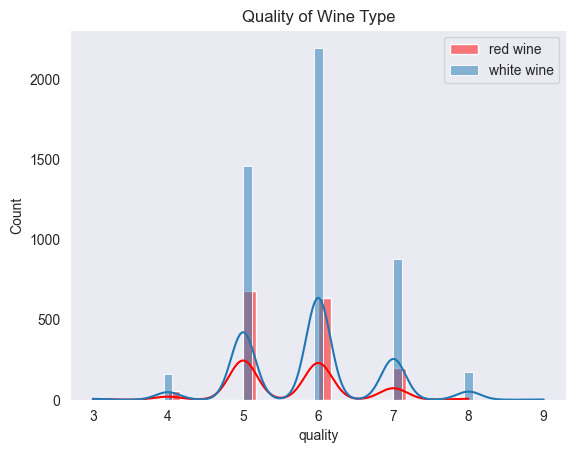

In [ ]:
sns.set_style('dark') #배경색 -> 다크(그래프와 배경 대비 용도이므로 상관x)
sns.histplot(red_wine_quality, kde = True, color = "red", label = 'red wine') #kde = 밀도 추정 함수, lebel = 범례(표 옆 이름)
sns.histplot(white_wine_quality, kde = True, label = 'white wine')
plt.title("Quality of Wine Type") #그래프 제목 보이기
plt.legend() #그래프 범례 보이기
plt.show() #그래프 그려줘

### 7.2 부분 회귀 플롯으로 시각화하기

In [118]:
import statsmodels.api as sm

### - fixed_acidity가 종속 변수 quality에 미치는 영향력을 시각화하기

In [ ]:
others = list(set(wine.columns).difference(set(["quality", "fixed_acidity"]))) #fixed_acidity의 결과를 보고싶어서 따로 빼는 것임(변인통제).
                                                #"quality", "fixed_acidity": 종속변수(y), 독립변수(x)

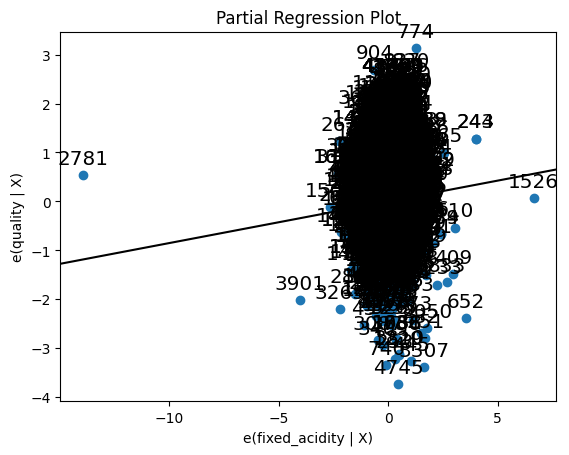

In [ ]:
p, resids = sm.graphics.plot_partregress("quality", "fixed_acidity", others, data = wine, ret_coords = True) #plot_partregress: 부분회귀
#p, resids: 그래프(예측값(선형)), 잔차(예측값 ~ 실제값의 차이)
#기울기: quality 잔차와 fixed_acidity 잔차 사이의 관계 -> 기울기 (+) 방향일수록 비례관계(유의미한, 영향력 있는 관계)임00000000000000000000000000000000 

- endog="quality",
- exog_i="fixed_acidity",
- exog_others=others
##### 키워드 있으면 plot_partregress 함수에서 순서없이 사용 가능, 안 적으면 위의 순서대로

### - 각 독립 변수가 종속 변수 quality에 미치는 영향력을 시각화하기

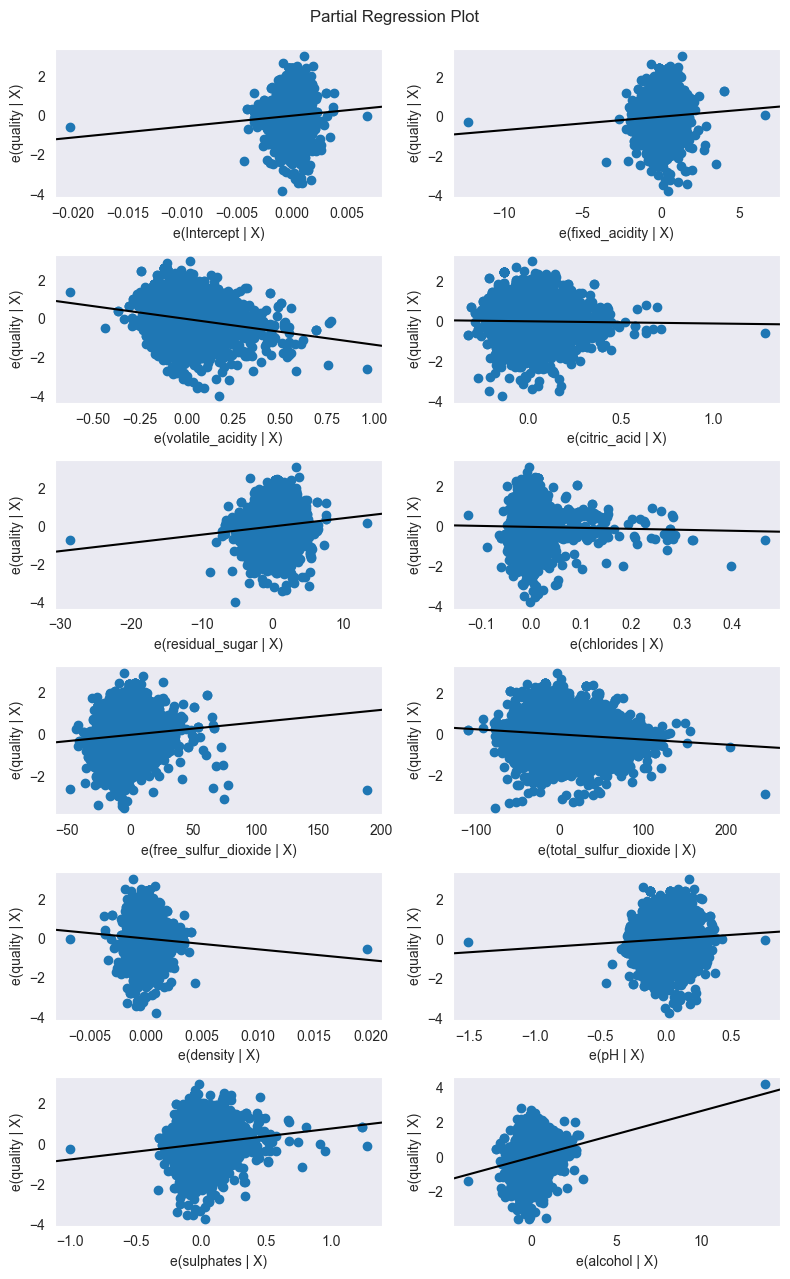

In [51]:
fig = plt.figure(figsize = (8, 13))
sm.graphics.plot_partregress_grid(regression_result, fig = fig)
plt.show()

------------------------------------------

## 펭귄을 다시 꺼내서...
- penguins = sns.load_dataset("penguins")
- t-검정
  - 같은 종에서 성별별 체중 차이(예> 아델리 수컷 vs.암컷)
- 회귀
  - body_mass_g ~ bill_length_mm + flipper_length_mm + species
- 부분 회귀 플롯
  - 날개 길이가 체중에 주는 "순수 영향" 보기

In [121]:
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [137]:
penguins[penguins["species"] == "Adelie"]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
147,Adelie,Dream,36.6,18.4,184.0,3475.0,Female
148,Adelie,Dream,36.0,17.8,195.0,3450.0,Female
149,Adelie,Dream,37.8,18.1,193.0,3750.0,Male
150,Adelie,Dream,36.0,17.1,187.0,3700.0,Female


In [139]:
print("#1> t-검정")
adelie = penguins[penguins['species'] == 'Adelie']
pMen = adelie.loc[adelie['sex'] == 'Male', 'body_mass_g']
pWomen = adelie.loc[adelie['sex'] == 'Female', 'body_mass_g']
stats.ttest_ind(pMen, pWomen, equal_var = False)

#equal_var: 등분산성
#statistic: 절댓값이 클수록 값간 차이가 있겠다
#pvalue: 작을수록(0에 가까울수록) 차이가 유의미하다! "0.05"를 기준으로 차이가 유의미한지 여부를 알 수 있음.
#df: 자유도. 표본 수치에 따라가는 편.

#1> t-검정


TtestResult(statistic=np.float64(13.126285923485874), pvalue=np.float64(6.402319748031793e-26), df=np.float64(135.69357893530383))

In [140]:
gentoo = penguins[penguins['species'] == 'Gentoo']
pMen = gentoo.loc[gentoo['sex'] == 'Male', 'body_mass_g']
pWomen = gentoo.loc[gentoo['sex'] == 'Female', 'body_mass_g']
stats.ttest_ind(pMen, pWomen, equal_var = False)

TtestResult(statistic=np.float64(14.761368414543291), pvalue=np.float64(1.8677596749117468e-28), df=np.float64(116.6435037751259))

In [141]:
chinstrap = penguins[penguins['species'] == 'Chinstrap']
pMen = chinstrap.loc[chinstrap['sex'] == 'Male', 'body_mass_g']
pWomen = chinstrap.loc[chinstrap['sex'] == 'Female', 'body_mass_g']
stats.ttest_ind(pMen, pWomen, equal_var = False)

TtestResult(statistic=np.float64(5.20773384899266), pvalue=np.float64(2.2644315514651406e-06), df=np.float64(62.575105077219284))

In [169]:
print("#2> 회귀 분석")
clean_penguins = penguins.dropna()
Rformula = 'body_mass_g ~ bill_length_mm + flipper_length_mm + species'
regression_result = ols(Rformula, data = clean_penguins).fit()
regression_result.summary()

#2> 회귀 분석


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     384.7
Date:                Thu, 04 Dec 2025   Prob (F-statistic):          1.88e-122
Time:                        16:31:54   Log-Likelihood:                -2410.6
No. Observations:                 333   AIC:                             4831.
Df Residuals:                     328   BIC:                             4850.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -3864.0732    533.592     -7.242      0.000   -4913.768   -2814.379
species[T.Chinstrap]  -732.4167     82.063     -8.925      0.000    -893.854    -570.980
species[T.Gentoo]      113.2542     89.206      1.270      0.205     -62.233     288.741
bill_length_mm          60.1173      7.207      8.341      0.000      45.939      74.295
flipper_length_mm       27.5443      3.209      8.583      0.000      21.231      33.858
==============================================================================
Omnibus:                        4.950   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.084   Jarque-Bera (JB):                4.875
Skew:                           0.296   Prob(JB):                       0.0874
Kurtosis:                       3.016   Cond. No.                     5.97e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.97e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [175]:
cul = clean_penguins.copy()
cul_predict = regression_result.predict(cul)
cul_predict

0      3472.029945
1      3633.798305
2      3929.790740
4      3658.279799
5      3731.951985
          ...     
338    4981.195891
340    4984.693247
341    5393.925619
342    4805.872670
343    5115.968381
Length: 333, dtype: float64

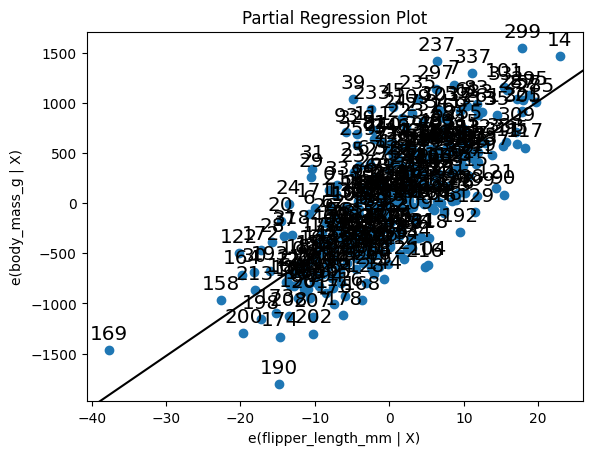

In [ ]:
others = list(set(penguins.columns).difference(set(['body_mass_g', 'flipper_length_mm',' island', 'sex', 'species'])))
p, resids = sm.graphics.plot_partregress("body_mass_g", "flipper_length_mm", others, data = clean_penguins, ret_coords = True)
# fig = plt.figure(figsize = (8, 13))
# sm.graphics.plot_partregress_grid(regression_result, fig = fig) #fig 사용하는 방식은 위에서 dropna() 사용 안해도 알아서 NaN 값 지워서 실행해줌
plt.show()

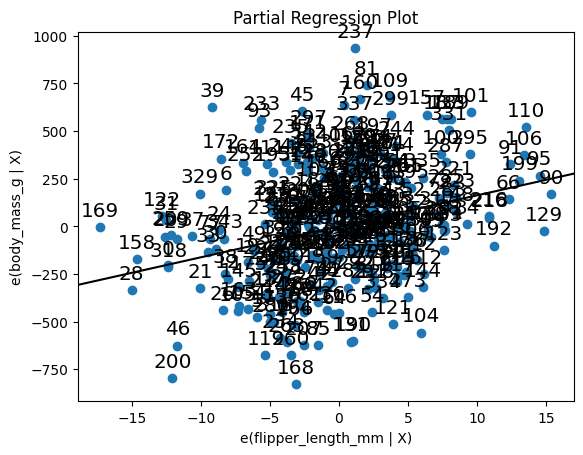

In [ ]:
others = list(penguins.columns.difference(['body_mass_g', 'flipper_length_mm'])) #틀렸던 이유: list 안해서 -> exog는 리스트만을 인식함
p, resids = sm.graphics.plot_partregress("body_mass_g", "flipper_length_mm", others, data = clean_penguins, ret_coords = True)
plt.show()

------------------------------------------

# [2] 상관분석 + 히트맵
#      타이타닉호 생존율 분석하기

## 3. 데이터 수집

#1. 목표 설정

- 타이타닉 호 생존자와 관련된 변수의 상관관계
- 상관 분석 위해 피어슨 상관 계수(얼마나 상관관계가 있는지 선형 분석 위한 피어슨 모델) 사용
- 생존과 가장 밀접한 변수 무엇인지 분석
- 변수간 상관관계 시각화해 분석

In [1]:
import seaborn as sns

In [2]:
import pandas as pd

In [11]:
titanic = sns.load_dataset("titanic")

In [12]:
titanic.to_csv('./7장_data/titanic.csv', index = False)

## 4. 데이터 준비

#### - 결측값 있는지 확인하기

In [13]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
titanic.isnull().sum()
#titanic.isnull() 했을 때 False면 값이 있음, True면 없는데, 이때 True의 개수를 카운트해주는 것임

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

#### - age 열의 결측값을 중앙값으로 치환하기

In [ ]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
#titanic['age'].fillna(titanic['age'].median()): titanic['age']에서 NaN 값인 것들을 괄호 안의 처리하여 .(콤마) 앞의 것에 집어넣음

#### - embarked 열의 결측값을 최빈값으로 치환하기

In [16]:
titanic['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [17]:
titanic['embarked'] = titanic['embarked'].fillna('S')

#### - embark_town 열의 결측값을 최빈값으로 치환하기

In [18]:
titanic['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [19]:
titanic['embark_town'] = titanic['embark_town'].fillna('Southampton')

#### - deck 열의 결측값을 최빈값으로 치환하기

In [20]:
titanic['deck'].value_counts()

deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

In [21]:
titanic['deck'] = titanic['deck'].fillna('C')

#### - 결측치가 다 채워졌는지 확인하기

In [22]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

## 5. 데이터 탐색

### 5.1 데이터의 기본 정보 탐색하기

In [23]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
titanic.survived.value_counts()
#0: 사망, 1: 생존

survived
0    549
1    342
Name: count, dtype: int64

In [25]:
titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

### 5.2 차트를 그려 데이터를 시각적으로 탐색하기

In [26]:
import matplotlib.pyplot as plt

In [27]:
titanic['survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

In [28]:
titanic['survived'][titanic['sex'] == 'male']

0      0
4      0
5      0
6      0
7      0
      ..
883    0
884    0
886    0
889    1
890    0
Name: survived, Length: 577, dtype: int64

In [29]:
titanic['survived'][titanic['sex'] == 'male'].value_counts()

survived
0    468
1    109
Name: count, dtype: int64

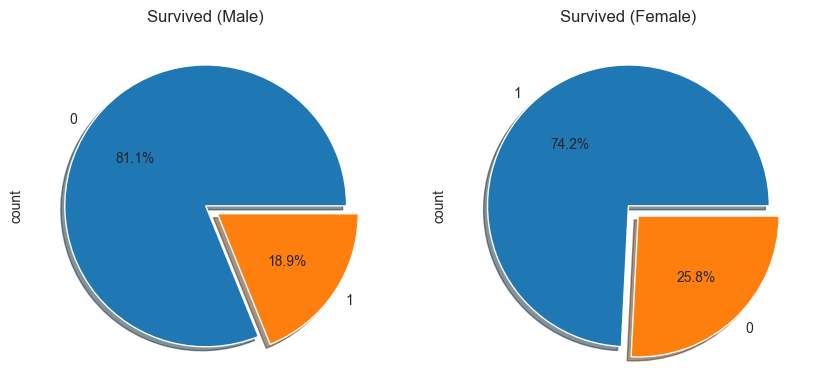

In [ ]:
f,ax = plt.subplots(1, 2, figsize = (10, 5)) #1행 2열 배치, figsize는 가로, 세로의 길이
titanic['survived'][titanic['sex'] == 'male'].value_counts().plot.pie(explode = [0,0.1], autopct = '%1.1f%%', ax = ax[0], shadow = True)
                                            #explode: 중심에서 벗어난 비율, [] 안의 내용은 파이차트위 중앙을 기준으로 왼쪽(파란) 차트, 오른쪽(주황) 차트가 떨어진 비율임
titanic['survived'][titanic['sex'] == 'female'].value_counts().plot.pie(explode = [0,0.1], autopct = '%1.1f%%', ax = ax[1], shadow = True)
ax[0].set_title('Survived (Male)')
ax[1].set_title('Survived (Female)')
plt.show()

원 그래프 그리기: 등급별 여성 남성의 비율을 원그래프 3개로 표현

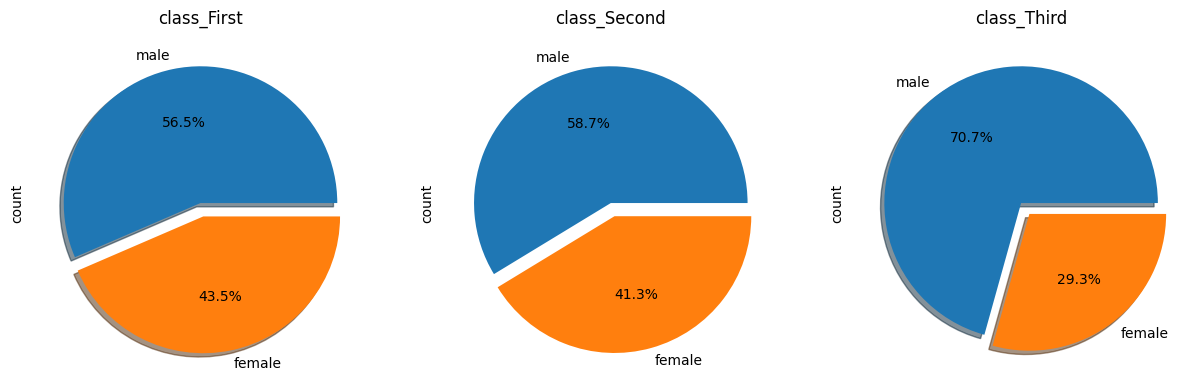

In [37]:
f,ax = plt.subplots(1, 3, figsize = (15, 5))
titanic['sex'][titanic['class'] == 'First'].value_counts().plot.pie(explode = [0,0.1], autopct = '%1.1f%%', ax = ax[0], shadow = True)
titanic['sex'][titanic['class'] == 'Second'].value_counts().plot.pie(explode = [0,0.1], autopct = '%1.1f%%', ax = ax[1], shadow = False)
titanic['sex'][titanic['class'] == 'Third'].value_counts().plot.pie(explode = [0,0.1], autopct = '%1.1f%%', ax = ax[2], shadow = True)
ax[0].set_title('class_First')
ax[1].set_title('class_Second')
ax[2].set_title('class_Third')
plt.show()

### 5.3 등급별 생존자 수를 차트로 나타내기

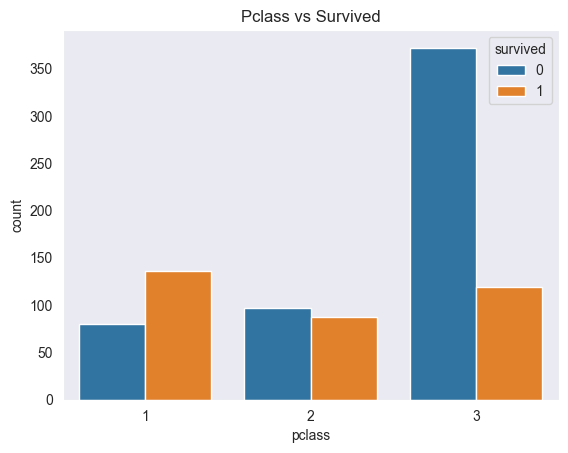

In [ ]:
sns.countplot(x='pclass', hue = 'survived', data = titanic) #hue: 어떤 것을 기준으로 카운트할 지를 결정 
plt.title('Pclass vs Survived')
plt.show()

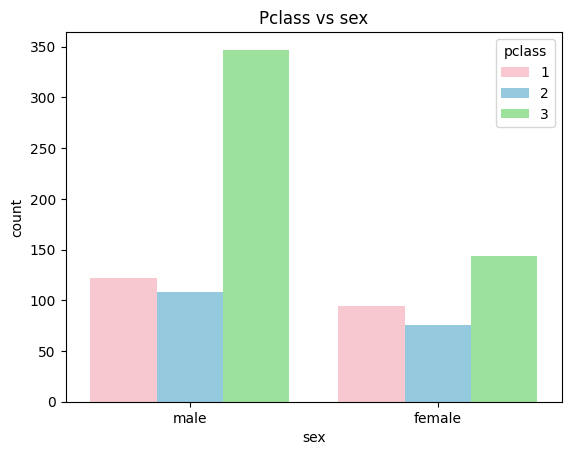

In [44]:
sns.countplot(x='sex', hue = 'pclass', data = titanic, palette=['pink', 'skyblue', 'lightgreen'])
plt.title('Pclass vs sex')
plt.show()

## 6. 데이터 모델링

### 6.1 상관분석을 위한 상관계수를 구하고 저장하기

In [45]:
titanic2 = titanic.select_dtypes(include=[int, float,bool]) 
titanic2.shape

(891, 8)

In [47]:
titanic2.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
0,0,3,22.0,1,0,7.2500,True,False
1,1,1,38.0,1,0,71.2833,False,False
2,1,3,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,False
4,0,3,35.0,0,0,8.0500,True,True


In [ ]:
titanic_corr = titanic2.corr(method = 'pearson') #method: pearson, spearman, kendall중에 선택

In [48]:
titanic_corr

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.247704,0.171647
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.247704,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.171647,-0.584471,-0.583398,-0.271832,0.404744,1.000000


대각선(1.0 값들) 기준으로 좌우 대칭
높은 값일수록 서로 상관관계 높은 편임

- 예> survived(0: 사망, 1:생존), adult_male(0: 성인남성 아님, 1: 성인남성임) -> -0.557080: 성인남성일수록 사망확률 높아짐

### [상관관계 결과 해석]

pclass - survived : 음의 상관 
→ 등급 숫자가 높을수록(=3등급) 생존률이 떨어진다
→ 1등급 > 2등급 > 3등급 순으로 생존률이 높았다

age - survived : 약한 음의 상관
→ 나이가 많다고 생존률이 특별히 떨어지는 건 아님
→ 단순히 큰 영향력은 없음

sibsp (부부·형제자매 수) - survived : 상관 거의 없음
→ 함께 탔다고 생존률이 크게 달라지는 건 아님

parch (부모·자녀 수) - survived : 약한 양의 상관
→ 아이와 함께 탄 어른, 아이, 엄마는 구조 우선 순위
→ 약한 수준이지만 생존률 증가와 관련 있음
→ 부모 자녀의 수가 많을 수록 생존율이 높아진다


fare - survived : 양의 상관
→ 비싼 표를 가진 사람일수록 생존률이 높음

adult_male - survived : 강한 음의 상관
→ 성인 남성일수록 생존률 급격히 감소

alone - survived : 약한 음의 상관
→ 혼자 탄 승객이 생존률이 낮았다

pclass - fare : (강한 음의 상관)
→ 등급이 낮을수록 값싼 표를 산 것

pclass - adult_male (약한 양의 상관)
→ 등급이 낮을수록 성인 남성이 많다

age - adult_male (강한 양의 상관)
→ 성인 남성은 당연히 나이가 많은 ‘성인’ → 관계가 강함

age - sibsp 음의 상관
→ 가족 동반 승객들은 대체로 나이가 적은 편

sibsp - parch 양의 상관
→ 가족 단위 여행 비율이 높음
→ 형제·배우자와 부모·자녀가 같이 있는 경우가 많음

adult_male ↔ alone 양의 상관
→ 성인 남성 중 혼자 탄 사람이 많다는 패턴이 있음

alone ↔ sibsp/parch 모두 음의 상관(당연함)
→ 동반자가 있으면 alone=0
→ 수학적으로도 반대 개념이라 음의 상관이 나오는 것이 자연스러움

In [49]:
titanic_corr.to_csv('./7장_data/titanic_corr.csv', index = False)

### 6.2 상관계수 확인하기 

#### - 저장한 titanic_corr.csv 파일을 열어서 저장된 상관계수를 확인해본다

### 6.3 특정 변수 사이의 상관계수 구하기 

In [50]:
titanic['survived'].corr(titanic['adult_male'])

np.float64(-0.5570800422053259)

In [51]:
titanic['survived'].corr(titanic['fare'])

np.float64(0.2573065223849622)

## 7. 결과 시각화

### 7.1 산점도로 상관 분석 시각화하기 

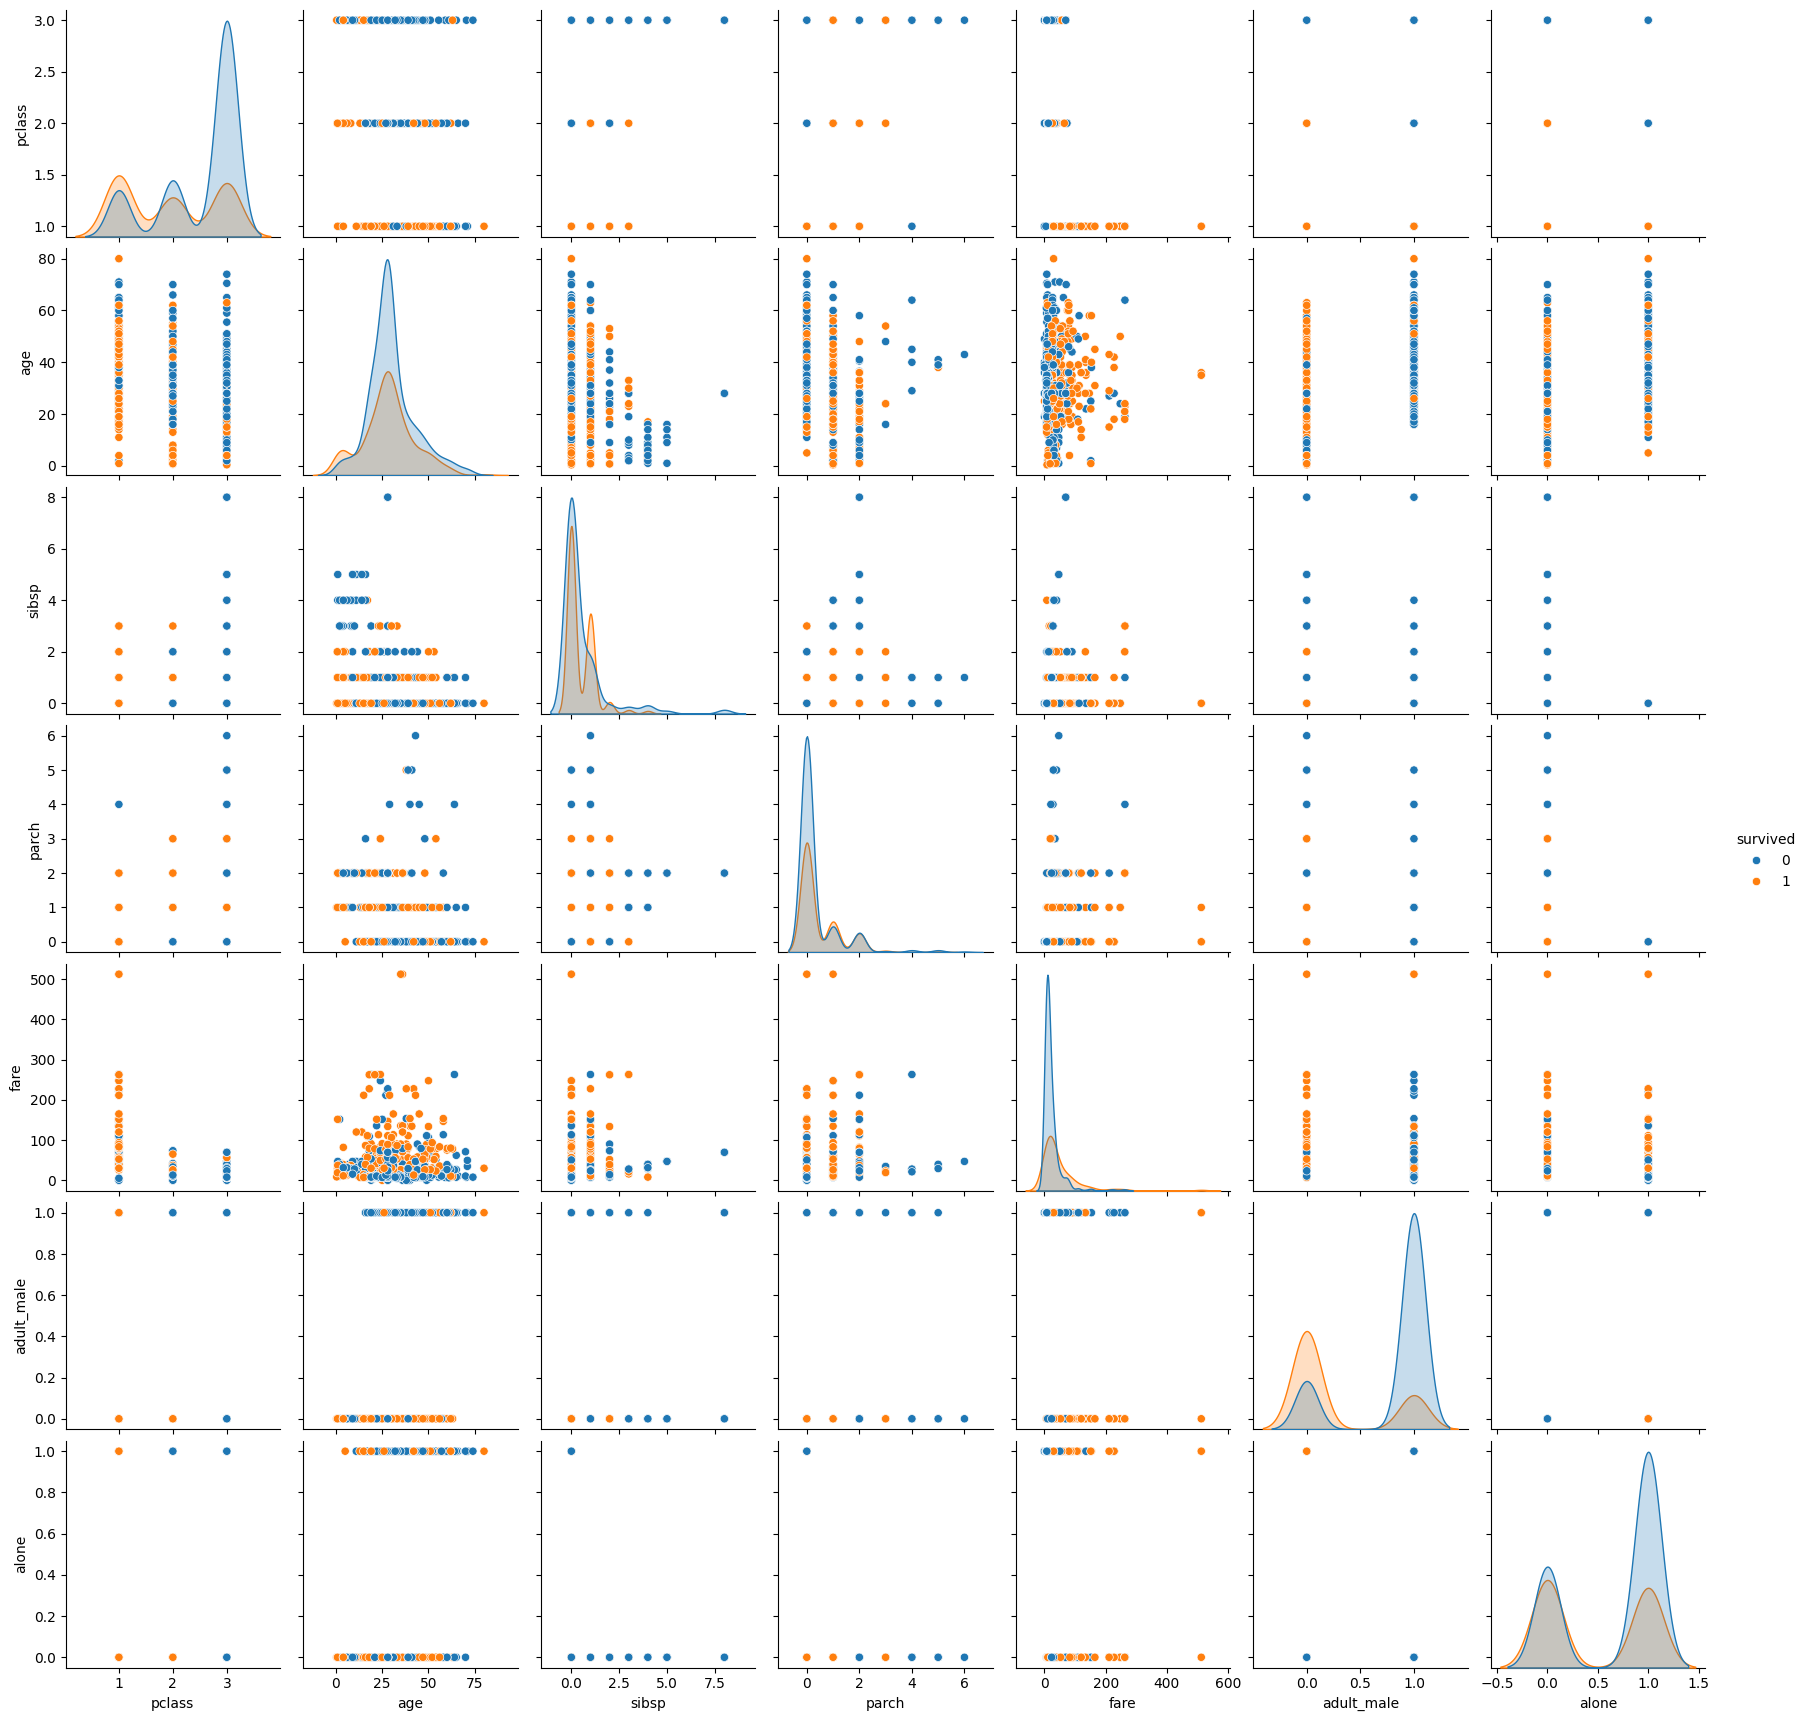

In [52]:
sns.pairplot(titanic, hue = 'survived')

plt.show()

### 7.2 두 변수의 상관관계 시각화하기

#### - 객실 등급과 생존의 상관관계를 seaborn 패키지의 catplot으로 시각화해보자

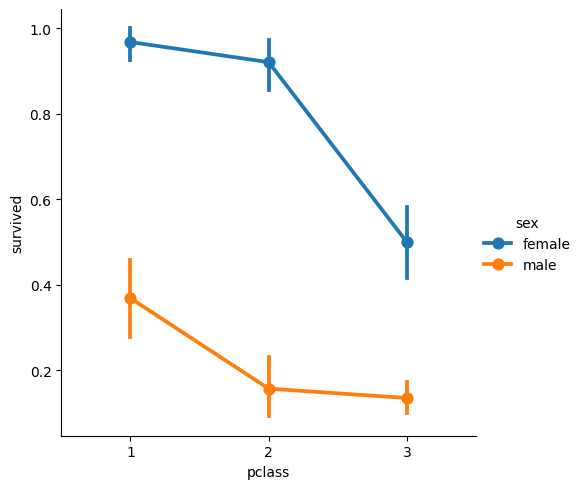

In [53]:
sns.catplot(x = 'pclass', y = 'survived', hue = 'sex', data = titanic, kind = 'point')

plt.show()

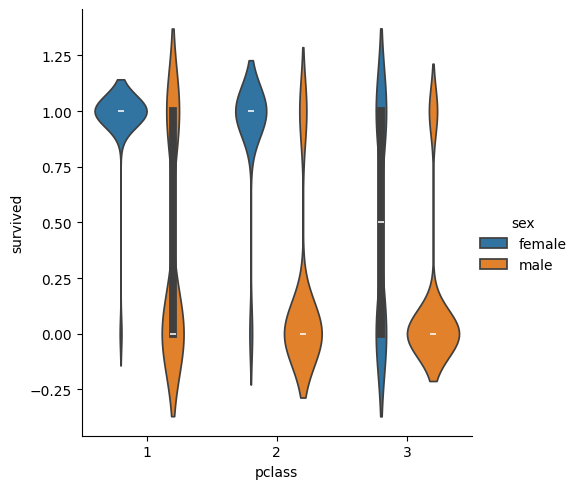

In [57]:
sns.catplot(x = 'pclass', y = 'survived', hue = 'sex', data = titanic, kind = 'violin') 
plt.show()

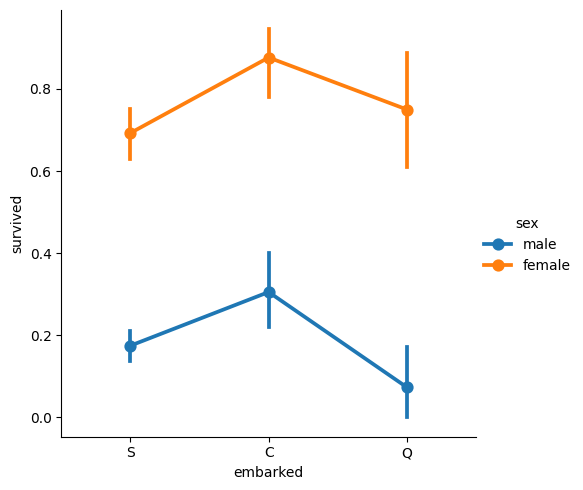

In [ ]:
sns.catplot(x = 'embarked', y = 'survived', hue = 'sex', data = titanic, kind = 'point') #kind: 범주형 변수마다 범위(최대~최소 사이) 내에서의 평균값을 점으로 잡고 그래프 그림

plt.show()

### 7.3 변수 사이의 상관 계수를 히트맵으로 시각화하기

In [58]:
def category_age(x):
    if x < 10:
        return 0
    elif x < 20:
        return 1
    elif x < 30:
        return 2
    elif x < 40:
        return 3
    elif x < 50:
        return 4
    elif x < 60:
        return 5
    elif x < 70:
        return 6
    else:
        return 7

In [59]:
titanic['age2'] = titanic['age'].apply(category_age)

In [60]:
titanic['sex'] = titanic['sex'].map({'male':1, 'female':0})

In [62]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age2
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False,2
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,3
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True,2
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,3
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True,3


In [63]:
titanic['family'] = titanic['sibsp'] + titanic['parch'] + 1

In [64]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age2,family
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False,2,2
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,3,2
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True,2,1
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,3,2
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True,3,1


In [65]:
titanic.to_csv('./7장_data/titanic3.csv', index = False)

In [66]:
heatmap_data = titanic[['survived', 'sex', 'age2', 'family', 'pclass', 'fare']]

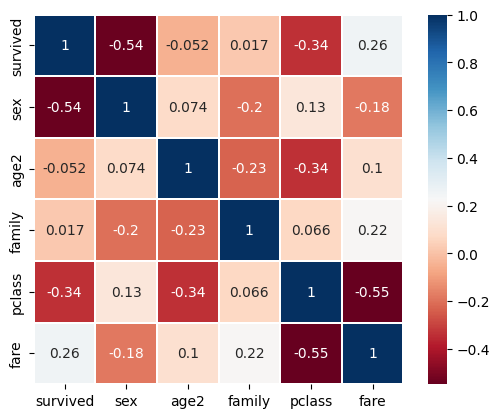

In [ ]:
colormap = plt.cm.RdBu #cmap = colormap: 그래프 우측 컬러 설정 -> 취향대로, 구글 검색 시 색깔 여러 개 나옴(seaborn color palettes)

sns.heatmap(heatmap_data.astype(float).corr(), linewidths = 0.1, vmax = 1.0, square = True, cmap = colormap, linecolor = 'white', annot = True,
annot_kws = {"size": 10})
#vmax, square:히트맵 정사각형으로 보이게 하는 설정
#annot: 각 칸에 값 표시 여부 설정
#annot_kws: 각 칸(어노테이션)의 크기 설정
plt.show()

# 펭귄을 다시 꺼내서...

### penguins = sns.load_dataset("penguins")

- 1) 결측치 확인 -> 전처리
- 2) 수치형 변수만 선택해 상관분석
- 3) bill_length를 카테고리로 나눠 분석
- 4) 히트맵 그리기
- 5) hue 사용해서 그룹 간 시각화
- 6) catplot 이용해 그래프 그리고 해석

In [68]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [119]:
penguins = sns.load_dataset("penguins")
penguins.info()
penguins.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [120]:
#결측값 있는 것 찾아서 중앙값으로 변경
penguins["bill_length_mm"] = penguins["bill_length_mm"].fillna(penguins["bill_length_mm"].median())
penguins["bill_depth_mm"] = penguins["bill_depth_mm"].fillna(penguins["bill_depth_mm"].median())
penguins["flipper_length_mm"] = penguins["flipper_length_mm"].fillna(penguins["flipper_length_mm"].median())
penguins["body_mass_g"] = penguins["body_mass_g"].fillna(penguins["body_mass_g"].median())

#결측치 행 제거
penguins.dropna(subset=["sex"], inplace=True)

#확인
penguins.info()
penguins.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [121]:
#상관분석: 수치형 변수만 선택
peng = penguins.select_dtypes(include=[int, float]) 
peng.shape
peng.head()

peng_corr = peng.corr(method = 'pearson')
peng_corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


In [122]:
#카테고리화: 59.6(최대) ~ 44.5(중앙) ~ 32.1(최소)
def bill_length(x):
    if x < 35:
        return 0
    elif x < 40:
        return 1
    elif x < 45:
        return 2
    elif x < 50:
        return 3
    elif x < 55:
        return 4
    else:
        return 5

In [ ]:
#bill_length를 카테고리로 나눠 분석
penguins["bill_lengths"] = penguins["bill_length_mm"].apply(bill_length)

penguins['sex_num'] = penguins['sex'].map({'Male':1, 'Female':0})
penguins['species_num'] = penguins['species'].map({'Adelie':0, 'Chinstrap':1, 'Gentoo':2})
penguins['island_num'] = penguins['island'].map({'Torgersen':0, 'Dream':1, 'Biscoe':2})

penguins #확인

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_lengths,sex_num,species_num,island_num
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1,1,0,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1,0,0,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,2,0,0,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1,0,0,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,3,0,2,2
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,3,0,2,2
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,4,1,2,2
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,3,0,2,2


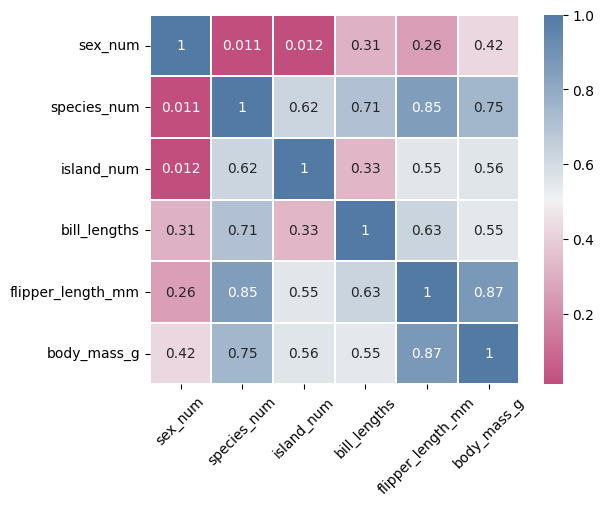

In [155]:
#히트맵 그리기
heatmap_data = penguins[['sex_num', 'species_num', 'island_num', 'bill_lengths','flipper_length_mm','body_mass_g']]

# colormap = plt.cm.RdBu
colormap = sns.diverging_palette(350, 245, s=60, as_cmap=True)

sns.heatmap(heatmap_data.astype(float).corr(), linewidths = 0.1, vmax = 1.0, square = True, cmap = colormap, linecolor = 'white', annot = True, annot_kws = {"size": 10})
plt.xticks(rotation = 45, fontsize = 10)
plt.show()

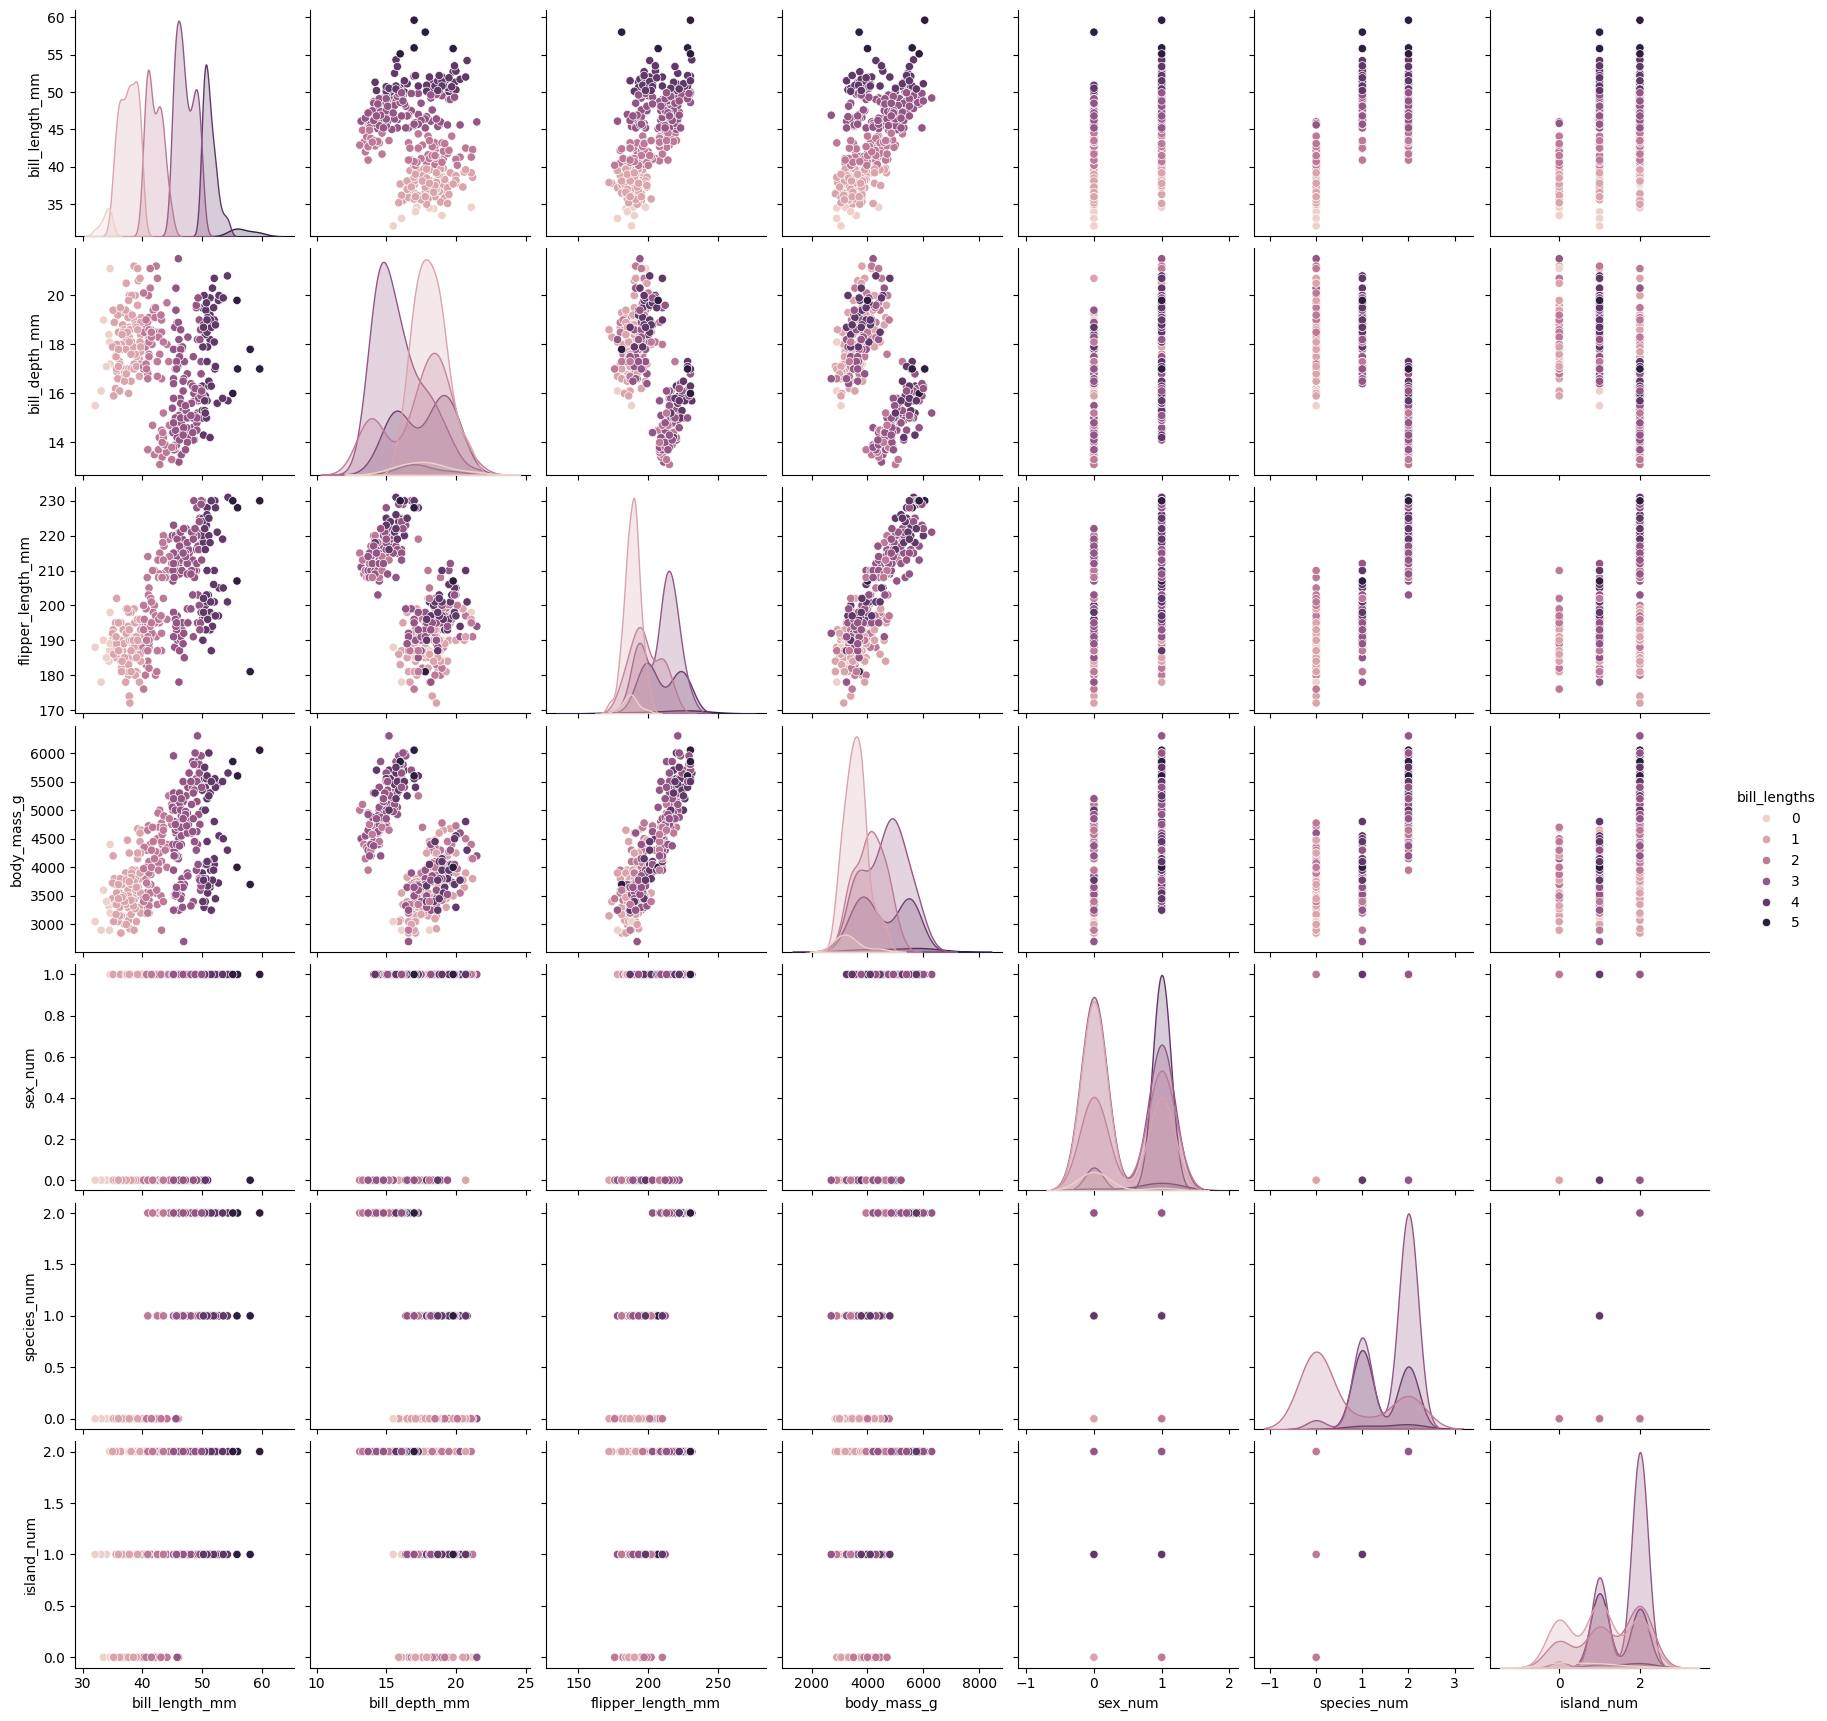

In [156]:
#시각화
sns.pairplot(penguins, hue = 'bill_lengths')
plt.show()

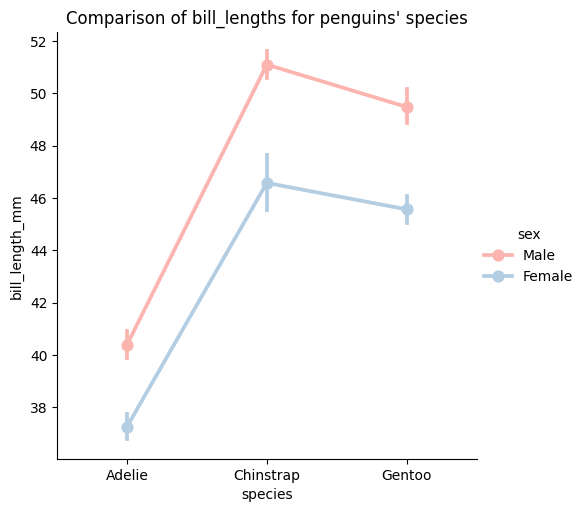

In [180]:
sns.catplot(x = 'species', y = 'bill_length_mm', hue = 'sex', data = penguins, kind = 'point', palette='Pastel1') #hue: 어떤 것을 기준으로 카운트할 지를 결정
plt.title('Comparison of bill_lengths for penguins\' species')
plt.show()